# LLM Benchmark ELT

The following notebook involves an ELT pipeline that ingests LLM performance benchmarks (intelligence scores, latency, pricing) from the *Artificial Analysis API*.

Data flows through a medallion architecture: **Bronze** (raw) → **Silver** (cleaned Delta Lake table partitioned by snapshot date) → **Gold** (ranked leaderboard + trends).

## 1. Importing & Logging

In [1]:
# Install dependencies
%pip install -r ../requirements.txt -q
%pip install --upgrade --force-reinstall --no-cache-dir pillow -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.core.logging import configure_logging
from src.core.config import load_config
from src.core.spark_session import get_or_create_spark
from src.bronze.ingest import fetch_models, flatten_data, save_raw
from src.silver.transform import transform
from src.silver.write_delta import write_to_delta, verify_delta_table

configure_logging("INFO")

## 2. Load Configuration

In [3]:
config = load_config()
print(f"Snapshot date: {config['snapshot_date']}")
print(f"Bronze dir:    {config['bronze_dir']}")
print(f"Silver dir:    {config['silver_dir']}")

Snapshot date: 2026-06-22
Bronze dir:    /mnt/c/Users/AbdallahYamani/Documents/Personal/llm-benchmark-transformation/data/bronze
Silver dir:    /mnt/c/Users/AbdallahYamani/Documents/Personal/llm-benchmark-transformation/data/silver


## 3. Extract — Fetch from API

In [4]:
raw_data = fetch_models(config["api_url"], config["api_key"])
print(f"Models fetched: {len(raw_data['data'])}")

2026-06-22 22:06:43 | src.bronze.ingest | INFO | Models fetched: 540 items


Models fetched: 540


## 4. Bronze — Flatten and Save Parquet

In [5]:
# Flatten to DataFrame
df_bronze = flatten_data(raw_data, config["snapshot_date"])
print(f"Bronze DataFrame: {len(df_bronze)} rows, {len(df_bronze.columns)} columns")
df_bronze.head()

Bronze DataFrame: 540 rows, 27 columns


,model_id,model_slug,release_date,creator_slug,price_1m_input_tokens,price_1m_output_tokens,median_output_tokens_per_second,median_time_to_first_token_seconds,median_time_to_first_answer_token,snapshot_date,...,eval_scicode,eval_math_500,eval_aime,eval_aime_25,eval_ifbench,eval_lcr,eval_terminalbench_hard,eval_terminalbench_v2_1,eval_tau2,eval_tau_banking
0,36f73aaf-d38a-4b56-a2b3-d04d17186910,gpt-oss-20b,2025-08-05,openai,0.05,0.2,221.967,0.679,9.690,2026-06-22,...,0.344,NaN,NaN,0.893333,0.651020,0.306667,0.106061,0.138577,0.602339,0.070103
1,16149b9c-a1e9-4669-a5cb-ff3c00d78f89,gpt-oss-20b-low,2025-08-05,openai,0.06,0.2,258.765,0.535,8.264,2026-06-22,...,0.340,NaN,NaN,0.623333,0.578231,0.310000,0.045455,NaN,0.502924,NaN
2,c99f3bde-7c08-4de8-bd5c-8ee9123ebffa,gpt-oss-120b-low,2025-08-05,openai,0.15,0.6,362.070,0.490,6.014,2026-06-22,...,0.360,NaN,NaN,0.666667,0.582993,0.436667,0.053030,NaN,0.450292,NaN
3,f0083258-8646-45b8-8082-7aaf6c2ea82a,gpt-oss-120b,2025-08-05,openai,0.15,0.6,347.580,0.512,6.266,2026-06-22,...,0.389,NaN,NaN,0.934417,0.689796,0.506667,0.234848,0.262172,0.657895,0.120275
4,4c111fbc-d13a-42b4-858c-1dc17fe3c1d1,grok-1,2024-03-17,xai,0.00,0.0,0.000,0.000,0.000,2026-06-22,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Save Parquet
parquet_path = save_raw(df_bronze, config["bronze_dir"], config["snapshot_date"])
print(f"Parquet saved: {parquet_path}")

2026-06-22 22:06:43 | src.bronze.ingest | INFO | Saved Parquet to /mnt/c/Users/AbdallahYamani/Documents/Personal/llm-benchmark-transformation/data/bronze/models_2026-06-22.parquet (540 rows)


Parquet saved: /mnt/c/Users/AbdallahYamani/Documents/Personal/llm-benchmark-transformation/data/bronze/models_2026-06-22.parquet


## 5. Spark Session

In [7]:
spark = get_or_create_spark()
print(f"Spark version: {spark.version}")

26/06/22 22:06:45 WARN Utils: Your hostname, WAbdallahY resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/06/22 22:06:45 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


:: loading settings :: url = jar:file:/home/ayamani/.local/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/ayamani/.ivy2/cache
The jars for the packages stored in: /home/ayamani/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-0e3a5b3c-e4f9-4e11-9b93-6be771fd3657;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.3.0 in central
	found io.delta#delta-storage;3.3.0 in central
	found org.antlr#antlr4-runtime;4.9.3 in central
:: resolution report :: resolve 194ms :: artifacts dl 7ms
	:: modules in use:
	io.delta#delta-spark_2.12;3.3.0 from central in [default]
	io.delta#delta-storage;3.3.0 from central in [default]
	org.antlr#antlr4-runtime;4.9.3 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   3   |   

Spark version: 3.5.4


## 6. Silver Transform

In [8]:
df_silver = transform(parquet_path, spark)
df_silver.show(5, truncate=False)

2026-06-22 22:06:52 | src.silver.transform | INFO | Silver transform complete — 540 rows produced
26/06/22 22:06:52 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+------------------------------------+----------------+------------+------------+--------------+---------------+---------------------+----------------------------------+---------------------------------+-------------+-----------------+-------------------------------------+-----------------------------------+-------------+---------+--------+------------------+------------+-------------+---------+-----------------+-----------------+-----------------+-----------------------+-----------------------+-----------------+------------------+
|model_id                            |model_name      |release_date|vendor      |input_1m_price|output_1m_price|output_tokens_per_sec|median_time_to_first_token_seconds|median_time_to_first_answer_token|snapshot_date|analysis_ai_index|eval_artificial_analysis_coding_index|eval_artificial_analysis_math_index|eval_mmlu_pro|eval_gpqa|eval_hle|eval_livecodebench|eval_scicode|eval_math_500|eval_aime|eval_aime_25     |eval_ifbench     |eval_lcr         |eval_termi

In [9]:
# Check schema
df_silver.printSchema()

root
 |-- model_id: string (nullable = true)
 |-- model_name: string (nullable = true)
 |-- release_date: date (nullable = true)
 |-- vendor: string (nullable = true)
 |-- input_1m_price: double (nullable = true)
 |-- output_1m_price: double (nullable = true)
 |-- output_tokens_per_sec: double (nullable = true)
 |-- median_time_to_first_token_seconds: double (nullable = true)
 |-- median_time_to_first_answer_token: double (nullable = true)
 |-- snapshot_date: date (nullable = true)
 |-- analysis_ai_index: double (nullable = true)
 |-- eval_artificial_analysis_coding_index: double (nullable = true)
 |-- eval_artificial_analysis_math_index: double (nullable = true)
 |-- eval_mmlu_pro: double (nullable = true)
 |-- eval_gpqa: double (nullable = true)
 |-- eval_hle: double (nullable = true)
 |-- eval_livecodebench: double (nullable = true)
 |-- eval_scicode: double (nullable = true)
 |-- eval_math_500: double (nullable = true)
 |-- eval_aime: double (nullable = true)
 |-- eval_aime_25: dou

## 7. Delta Write

In [10]:
write_to_delta(df_silver, config["silver_dir"])

2026-06-22 22:06:55 | src.silver.write_delta | INFO | Silver write complete — 540 rows persisted to /mnt/c/Users/AbdallahYamani/Documents/Personal/llm-benchmark-transformation/data/silver/models


## 8. Verify Delta Table

In [11]:
summary = verify_delta_table(config["silver_dir"], spark)
print(f"Rows: {summary['row_count']}")
print(f"Partitions: {summary['partition_count']}")
print(f"History entries: {len(summary['history'])}")

2026-06-22 22:07:02 | src.silver.write_delta | INFO | Silver verification passed — 540 rows, 1 partitions


Rows: 540
Partitions: 1
History entries: 4


## 9. Gold Build

In [12]:
from src.gold.transform import compute_model_rankings, compute_model_trends
from src.gold.write_delta import write_gold_table

# Read Silver Delta for Gold
silver_path = str(config["silver_dir"] / "models")
df_all = spark.read.format("delta").load(silver_path)
df_snapshot = df_all.filter(df_all["snapshot_date"] == config["snapshot_date"])

# Build and write Gold tables
rankings = compute_model_rankings(df_snapshot, config["snapshot_date"])
write_gold_table(rankings, config["gold_dir"], "model_leaderboard")

trends = compute_model_trends(df_all)
write_gold_table(trends, config["gold_dir"], "model_trends")

2026-06-22 22:07:06 | src.gold.transform | INFO | Gold rankings computed — 283 models ranked
26/06/22 22:07:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/22 22:07:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/22 22:07:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/22 22:07:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/22 22:07:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/22 22:07:07 WARN WindowExec: No Partition Defined for Window operation! Movi

## 10. Verify Gold

In [13]:
gold_leaderboard = spark.read.format("delta").load(str(config["gold_dir"] / "model_leaderboard"))
gold_trends = spark.read.format("delta").load(str(config["gold_dir"] / "model_trends"))

print(f"Leaderboard: {gold_leaderboard.count()} rows")
print(f"Trends: {gold_trends.count()} rows")
gold_leaderboard.printSchema()

Leaderboard: 283 rows
Trends: 540 rows
root
 |-- snapshot_date: date (nullable = true)
 |-- rank: integer (nullable = false)
 |-- model_id: string (nullable = true)
 |-- model_name: string (nullable = true)
 |-- vendor: string (nullable = true)
 |-- composite_score: double (nullable = true)
 |-- intelligence_norm: double (nullable = true)
 |-- speed_norm: double (nullable = true)
 |-- price_norm: double (nullable = true)
 |-- avg_price_per_1m_tokens: double (nullable = true)
 |-- intelligence_per_dollar: double (nullable = true)
 |-- cost_tier: string (nullable = false)
 |-- efficiency_rank: integer (nullable = false)



In [14]:
import matplotlib.pyplot as plt

# Headline result: best model overall and best value
best = gold_leaderboard.orderBy("rank").first()
best_value = gold_leaderboard.orderBy("efficiency_rank").first()
print(f"\U0001F3C6 Best overall: {best['model_name']} by {best['vendor']} "
      f"(composite score {best['composite_score']:.1f})")
print(f"\U0001F4B0 Best value:   {best_value['model_name']} by {best_value['vendor']} "
      f"({best_value['intelligence_per_dollar']:.1f} intelligence per $/1M tokens)")

# Top 10 models by composite score
top10 = gold_leaderboard.orderBy("rank").limit(10).toPandas()
print("\nTop 10 Models:")
print(top10[["rank", "model_name", "vendor", "composite_score", "cost_tier"]].to_string(index=False))

🏆 Best overall: mercury-2 by inception (composite score 72.0)
💰 Best value:   hypernova-60b by multiversecomputing (245.6 intelligence per $/1M tokens)

Top 10 Models:
 rank              model_name    vendor  composite_score cost_tier
    1               mercury-2 inception        71.973059    budget
    2        gemini-3-5-flash    google        68.783649   premium
    3                 glm-5-2       zai        66.607139   premium
    4                 gpt-5-4    openai        66.440953   premium
    5         claude-opus-4-8 anthropic        65.159442   premium
    6 gemini-3-5-flash-medium    google        64.323226   premium
    7             qwen3-7-max   alibaba        63.880388   premium
    8                 gpt-5-5    openai        63.164923   premium
    9         claude-opus-4-7 anthropic        62.735908   premium
   10            gpt-5-5-high    openai        62.089666   premium


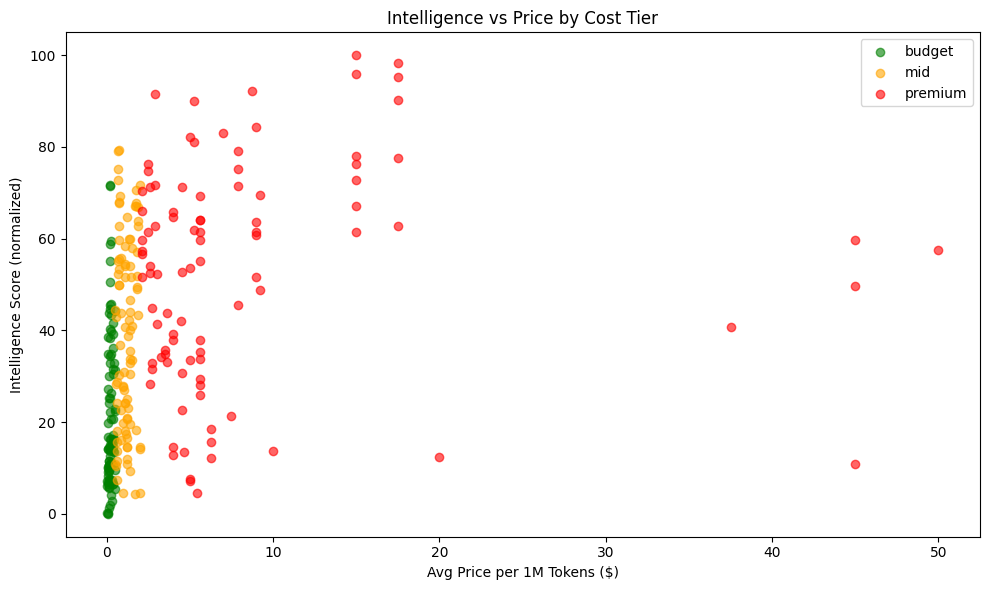

In [15]:
df_plot = gold_leaderboard.filter("cost_tier IS NOT NULL").toPandas()

colors = {"budget": "green", "mid": "orange", "premium": "red"}
fig, ax = plt.subplots(figsize=(10, 6))
for tier, group in df_plot.groupby("cost_tier"):
    ax.scatter(group["avg_price_per_1m_tokens"], group["intelligence_norm"],
               label=tier, color=colors[tier], alpha=0.6)
               
ax.set_xlabel("Avg Price per 1M Tokens ($)")
ax.set_ylabel("Intelligence Score (normalized)")
ax.set_title("Intelligence vs Price by Cost Tier")
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
spark.stop()